In [20]:
from fluke import DDict, FlukeENV
from fluke.data import DataSplitter
from fluke.data.datasets import Datasets
from fluke.evaluation import ClassificationEval
from fluke.algorithms.fedavg import FedAVG

import torch
import torch.nn as nn
import numpy as np
import time
import hashlib
import json as jsonlib
import tenseal as ts
import hashlib
import matplotlib.pyplot as plt
from CNN import *

FlukeENV().set_seed(42)
device = 'mps' if torch.backends.mps.is_available() else ('cuda' if torch.cuda.is_available() else 'cpu')
FlukeENV().set_device(device)

device(type='mps')

## TenSEAL Encryption Setup
An open-source library for homomorphic encryption by microsoft — [github.com/OpenMined/TenSEAL](https://github.com/OpenMined/TenSEAL)

In [2]:
context = ts.context(ts.SCHEME_TYPE.CKKS, poly_modulus_degree=8192,
                     coeff_mod_bit_sizes=[60, 40, 40, 60])
context.global_scale = 2**40
context.generate_galois_keys()

#ex
a = ts.ckks_vector(context, [1.0, 2.0, 3.0])
b = ts.ckks_vector(context, [4.0, 5.0, 6.0])
print(f"Test: [1,2,3]+[4,5,6] = {(a+b).decrypt()}")

Test: [1,2,3]+[4,5,6] = [4.99999999816365, 7.000000001391589, 9.000000004420782]


In [3]:
encrypted_hex = a.serialize().hex()
print(" a is encrypted to",encrypted_hex[:100]),len(encrypted_hex)

 a is encrypted to 0a010312f3b4145ea1100401020000731a05000000000028b52ffda061000600a45a0e8efddfd0722d10a0bc66968ed20376


(None, 668934)

## Encryption of model weights
Tenseal cannot read the prameters layer by layer So we need to convert the weights of model perameters into list and set back the list ot original parameters uusing set_flat_weights 

In [4]:
def get_flat_weights(model):
    flat_parameters = []
    for parameter in model.parameters():
        layer_list = parameter.data.flatten().tolist()
        for value in layer_list:
            flat_parameters.append(value)
    return flat_parameters

def set_flat_weights(model, flat_w):
    idx = 0
    for p in model.parameters():
        size = p.numel()
        p.data = torch.FloatTensor(flat_w[idx:idx+size]).reshape(p.shape)
        idx += size

In [5]:
def encrypted_aggregate(client_models, ctx, n):
    #the encrupted weights are converted to chunks of size 4096
    chunk_size = 4096
    encrypted = []
    for m in client_models:
        w = get_flat_weights(m)
        encrypted.append([ts.ckks_vector(ctx, w[i : i + chunk_size]) for i in range(0, len(w), chunk_size)])
    avg = [sum(chunks) * (1 / n) for chunks in zip(*encrypted)]
    dec = []
    for c in avg:
        dec.extend(c.decrypt())
    total = sum(p.numel() for p in client_models[0].parameters())
    return dec[:total]

## Blockchain for Model Update Logging
A lightweight blockchain that creates a **tamper-proof audit trail** of every FL round.
Each block stores SHA-256 hashes of the global model and each client's model, linking to the previous block.

In [6]:
class ModelChain:
    def __init__(self):
        # for the first round
        self.chain = [{'hash': '0', 'data': '"'}]

    def log_round(self, round_num, global_model, client_models, accuracy):
        g_hash = hashlib.sha256(str(get_flat_weights(global_model)[:100]).encode()).hexdigest()[:16]
        c_hashes = [hashlib.sha256(str(get_flat_weights(m)[:100]).encode()).hexdigest()[:16] for m in client_models]
        
        block = {
            'round': round_num,
            'accuracy': accuracy,
            'global_hash': g_hash,
            'client_hashes': c_hashes,
            'previous_hash': self.chain[-1]['hash']
        }
        
        # block hash using its data contents
        block['hash'] = hashlib.sha256(str(block['previous_hash'] + str(round_num)).encode()).hexdigest()[:16]
        self.chain.append(block)

    def verify(self):
        for i in range(1, len(self.chain)):
            if self.chain[i]['previous_hash'] != self.chain[i-1]['hash']:
                print("broken at chain",i)
        
        return "Chain valid and verified"

**From NonIID_Simulation:**

```The FedAVG algorithm claimed an accuracy of 77.7% on NON-IID (label_dirichlet_skew) with min_ex_class 4 data distribution```

In [7]:
mnist_data = Datasets.get('mnist', path='./data')
num_clients, num_rounds = 5, 10

In [27]:
def algo():
    return FedAVG(n_clients=num_clients,
                      data_splitter=DataSplitter(dataset=mnist_data,
                                                 distribution='dir',
                                                 dist_args=DDict(min_ex_class=4)),
                      hyper_params=DDict(model=MNIST_CNN(),
                                         client=DDict(batch_size=32,
                                                      local_epochs=3,
                                                      loss='CrossEntropyLoss',
                                                      optimizer=DDict(lr=0.01),
                                                      scheduler=DDict(step_size=10, gamma=1.0)),
                                         server=DDict(weighted=False)))

## FedAvg + HE (Encrypted Aggregation + Blockchain Logging)

In [9]:
def run_secure_fl(algo, ev, ctx, n_clients, n_rounds, label=''):
    chain = ModelChain()
    accuracies = []
    server_to_client_time=[]
    client_to_server_time = []

    for r in range(n_rounds):
        # server to client broadcast 
        t0 = time.time()
        clients = algo.server.get_eligible_clients(1.0)
        algo.server.broadcast_model(clients)
        
        server_to_client_time.append(time.time() - t0)
        # client local training
        for c in clients:
            c.local_update(r + 1)

        t1 = time.time()

        # client to server
        client_models = algo.server.receive_client_models(clients, state_dict=False)
        models = list(client_models)
        avg_weights = encrypted_aggregate(models, ctx, n_clients)
        set_flat_weights(algo.server.model, avg_weights)
        
        client_to_server_time.append(time.time() - t1)

        algo.server._rounds += 1
        metrics = algo.server.evaluate(ev, algo.server.test_set, round=r+1)
        acc = metrics['accuracy'] * 100
        accuracies.append(acc)

        chain.log_round(r+1, algo.server.model, models, acc)

    return accuracies, server_to_client_time, client_to_server_time, chain

## Model trainig

In [10]:
%%time
he_algo = algo()
he_eval = ClassificationEval(eval_every=1, n_classes=10)
FlukeENV().set_evaluator(he_eval)

he_accs, he_s2c, he_c2s, he_chain = run_secure_fl(
    he_algo, he_eval, context, num_clients, num_rounds, label='HE'
)

print(f"Model Accuracy: {he_accs[-1]:.2f}%")
print(f"Verification: {he_chain.verify()}")


block_df = pd.DataFrame(he_chain.chain)
display(block_df)

Model Accuracy: 94.27%
Verification: Chain valid and verified


,hash,data,round,accuracy,global_hash,client_hashes,previous_hash
0,0,"""",NaN,NaN,NaN,NaN,NaN
1,938db8c9f82c8cb5,NaN,1.0,33.38,f672f1bc2b64e7a4,"[655cf682c53369ca, 8c12221791a72a80, 432d0d98a...",0
2,86dcaeb201cab973,NaN,2.0,68.03,af8f95134ac05e26,"[7d11ef265a09b2ce, 5cb33ae8c9a88b6d, 21e51e33c...",938db8c9f82c8cb5
3,e7f8a5d0f3dcc9a0,NaN,3.0,82.01,ea55f57581ea5ab0,"[a4074358a34b500a, dca1876457c47968, d75a28978...",86dcaeb201cab973
4,5dea4d5282c69b69,NaN,4.0,87.86,c2f19b883e089d73,"[ea3bfbf1cf89f495, 2b105a913925caa7, a80e2711e...",e7f8a5d0f3dcc9a0
5,5ed35dc39299fcb0,NaN,5.0,90.47,7651786cdc48445c,"[0d7ac1391378a675, 20bfe583f671a313, 7e4e956b7...",5dea4d5282c69b69
6,ab896920b4e3b38d,NaN,6.0,93.12,1eff82646fb14447,"[9c8c7c723cfa7f72, 074b857e57583521, 959588a46...",5ed35dc39299fcb0
7,7735d303e210355a,NaN,7.0,92.40,980988d296731dd5,"[1fcd0e4a60d1e38f, 87e780c35a75bd9b, 250086fef...",ab896920b4e3b38d
8,52ba3b80cc8270e4,NaN,8.0,93.27,e963b213ba02f5d7,"[3d91a6f0fd272970, 5dd95bb9de0f0545, 9d7f3f7af...",7735d303e210355a
9,bd3f4c7cf7be6a02,NaN,9.0,94.26,9aaf593c6c1dc8d1,"[4c2d3a77bd51b9fe, 5507091f12229d48, cebe8e2aa...",52ba3b80cc8270e4


CPU times: user 3min 22s, sys: 41.5 s, total: 4min 3s
Wall time: 5min 42s


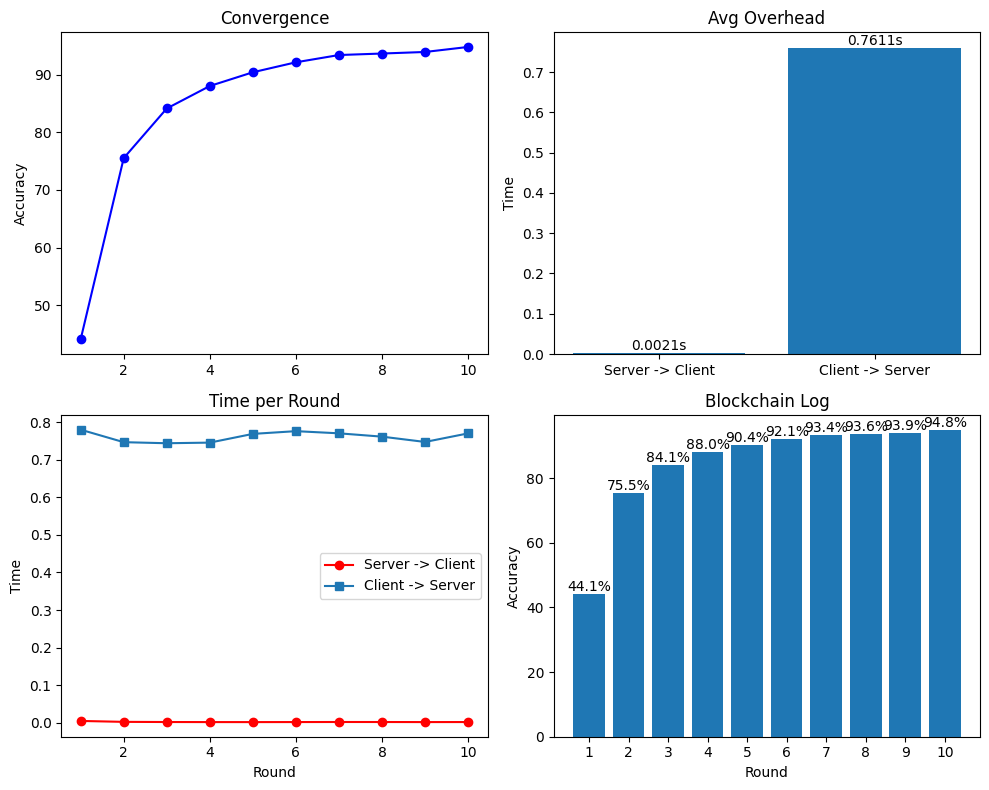

In [25]:
fig, ax = plt.subplots(2, 2, figsize=(10, 8))
r_range = range(1, num_rounds + 1)

ax[0, 0].plot(r_range, he_accs, marker='o',color='b')
ax[0, 0].set(title='Convergence', ylabel='Accuracy')

bars = ax[0, 1].bar(['Server -> Client', 'Client -> Server'], [sum(he_s2c)/num_rounds, sum(he_c2s)/num_rounds])
[ax[0, 1].text(b.get_x() + b.get_width()/2, b.get_height(), f'{b.get_height():.4f}s', ha='center', va='bottom') for b in bars]
ax[0, 1].set(title='Avg Overhead', ylabel='Time')

ax[1, 0].plot(r_range, he_s2c, marker='o', label='Server -> Client',color='r')
ax[1, 0].plot(r_range, he_c2s, marker='s', label='Client -> Server')
ax[1, 0].set(title='Time per Round', xlabel='Round', ylabel='Time')
ax[1, 0].legend()

b_data = he_chain.chain[1:]
bars_bc = ax[1, 1].bar([b['round'] for b in b_data], [float(b['accuracy']) for b in b_data])
[ax[1, 1].text(b.get_x() + b.get_width()/2, b.get_height(), f'{b.get_height():.1f}%', ha='center', va='bottom') for b in bars_bc]
ax[1, 1].set(title='Blockchain Log', xlabel='Round', ylabel='Accuracy', xticks=[b['round'] for b in b_data])

plt.tight_layout()
plt.show()

In [12]:
test_chain = ModelChain()
test_chain.log_round(1, he_algo.server.model, [he_algo.server.model], 85.0)
test_chain.log_round(3, he_algo.server.model, [he_algo.server.model], 90.0)

print(test_chain.verify())

test_chain.chain[1]['hash']="zxy"

print("After tamper:", test_chain.verify())

Chain valid and verified
broken at chain 2
After tamper: Chain valid and verified


In [18]:
csv_data = CSVDataset('./data/heart.csv', target=-1)

diabetes_algo = algo()
he_eval = ClassificationEval(eval_every=1, n_classes=10)
FlukeENV().set_evaluator(he_eval)

he_accs, he_s2c, he_c2s, he_chain = run_secure_fl(
    diabetes_algo, he_eval, context, num_clients, num_rounds, label='HE'
)

print(f"Model Accuracy: {he_accs[-1]:.2f}%")
print(f"Verification: {he_chain.verify()}")


block_df = pd.DataFrame(he_chain.chain)
display(block_df)

Model Accuracy: 94.47%
Verification: Chain valid and verified


,hash,data,round,accuracy,global_hash,client_hashes,previous_hash
0,0,"""",NaN,NaN,NaN,NaN,NaN
1,938db8c9f82c8cb5,NaN,1.0,16.05,fb33a4c9de6b2a1d,"[90e4df68e19791e5, ce889a33e283b365, 341dada94...",0
2,86dcaeb201cab973,NaN,2.0,67.98,0d1888f831472f82,"[74bf995c7024d7b8, 8f697a2ffc914f5a, f1ebf976b...",938db8c9f82c8cb5
3,e7f8a5d0f3dcc9a0,NaN,3.0,83.19,58cd51ed755a8d14,"[6ecebcd02ec250ae, 0ac34bc21bd9de4f, aa7309b49...",86dcaeb201cab973
4,5dea4d5282c69b69,NaN,4.0,88.86,3d16efc3582564ba,"[c2b4c4177dc39a69, 13655a1ae7d9c09b, 2b47d0c43...",e7f8a5d0f3dcc9a0
5,5ed35dc39299fcb0,NaN,5.0,89.08,7cdd6435e3799740,"[e9a4fc09428de314, 28ddf3658f08f542, 0abe172ab...",5dea4d5282c69b69
6,ab896920b4e3b38d,NaN,6.0,91.43,63ec4386953cff59,"[b688eb0e290d1a57, 0a4dc7b5980fe85c, b0ac3bc52...",5ed35dc39299fcb0
7,7735d303e210355a,NaN,7.0,91.61,1851251b34baddd1,"[06074d8908597539, ebb8eae5a850130f, 530a71a52...",ab896920b4e3b38d
8,52ba3b80cc8270e4,NaN,8.0,92.97,109bff16c5722b24,"[286195eaeea9b748, bd007d7935d3e2d4, b6ca292d5...",7735d303e210355a
9,bd3f4c7cf7be6a02,NaN,9.0,93.65,9b2129141cec16ec,"[c06fef34efbda54f, a3f1382185bdd605, cd3436b11...",52ba3b80cc8270e4


In [19]:
csv_data = CSVDataset('heart.csv', target=-1)

diabetes_algo = algo()
he_eval = ClassificationEval(eval_every=1, n_classes=10)
FlukeENV().set_evaluator(he_eval)

he_accs, he_s2c, he_c2s, he_chain = run_secure_fl(
    diabetes_algo, he_eval, context, num_clients, num_rounds, label='HE'
)

print(f"Model Accuracy: {he_accs[-1]:.2f}%")
print(f"Verification: {he_chain.verify()}")


block_df = pd.DataFrame(he_chain.chain)
display(block_df)

Model Accuracy: 94.78%
Verification: Chain valid and verified


,hash,data,round,accuracy,global_hash,client_hashes,previous_hash
0,0,"""",NaN,NaN,NaN,NaN,NaN
1,938db8c9f82c8cb5,NaN,1.0,44.07,a840bdab5a935bc3,"[59214fd6df22b64b, 5c40a66b4a15536f, e5c7f9eca...",0
2,86dcaeb201cab973,NaN,2.0,75.50,f2b11f635c429a3a,"[08f74ff8a793ba7f, add138346f216a67, 719a76509...",938db8c9f82c8cb5
3,e7f8a5d0f3dcc9a0,NaN,3.0,84.11,91dd40feff53ef47,"[94bf00ca878ac62b, 2904b5fc5d580ff5, a13fbf57a...",86dcaeb201cab973
4,5dea4d5282c69b69,NaN,4.0,88.01,786353467f165122,"[1a5dd5a1f0dd754b, 2ecb0a228cfb372e, 8d2ddbf40...",e7f8a5d0f3dcc9a0
5,5ed35dc39299fcb0,NaN,5.0,90.39,1292b96b0425438d,"[a92a84a5997e9649, cb8f6b891e4b6149, 1b873db0a...",5dea4d5282c69b69
6,ab896920b4e3b38d,NaN,6.0,92.12,2554c085f371e17d,"[3b0c609f2ad8a39a, c7d6d34587ac207c, a21e502f9...",5ed35dc39299fcb0
7,7735d303e210355a,NaN,7.0,93.38,c670575a83fb2f07,"[d2642e8dce619ac0, 61e9b3584b708b06, 2e32f0a2f...",ab896920b4e3b38d
8,52ba3b80cc8270e4,NaN,8.0,93.64,a9562d8e6275790b,"[f519717bd0ed3a09, 7ad20aff4a63a4f6, 23e10d4e6...",7735d303e210355a
9,bd3f4c7cf7be6a02,NaN,9.0,93.91,2c6827f4f4dfcf27,"[7d0cb30298519809, 8bd61f90037d40ae, bb3359a56...",52ba3b80cc8270e4
